<a href="https://colab.research.google.com/github/AnujikaSasindi/sri-lanka-tourism-sentiment-analysis/blob/Main/Attraction_Prediction_Model_3_(Roberta)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers[torch] accelerate datasets evaluate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 80.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


In [ ]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx to balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx
Shape of dataset: (7164, 11)

Column names:
['Location_Name', 'Located_City', 'Location_Type', 'Title', 'Text', 'Review_Text', 'Rating', 'Sentiment', 'Cluster_Text', 'Attraction_Cluster', 'Attraction_Category']

First 5 rows:


,Location_Name,Located_City,Location_Type,Title,Text,Review_Text,Rating,Sentiment,Cluster_Text,Attraction_Cluster,Attraction_Category
0,Handunugoda Tea Estate,Ahangama,Farms,Wonderful Experience,This was our third tea factory tour during our...,Wonderful Experience This was our third tea fa...,5,Positive,Handunugoda Tea Estate Farms Wonderful Experie...,4,Tea Plantations & Factory Tours
1,Glenloch Tea Factory,Katukitula,Farms,In-TEA-resting,A worth visit for everyone who drinks tea. Gui...,In-TEA-resting A worth visit for everyone who ...,4,Positive,Glenloch Tea Factory Farms In-TEA-resting A wo...,4,Tea Plantations & Factory Tours
2,Handunugoda Tea Estate,Ahangama,Farms,"The best tea experience, great history","Hidden away in a beautiful stretch of green, t...","The best tea experience, great history Hidden ...",5,Positive,Handunugoda Tea Estate Farms The best tea expe...,4,Tea Plantations & Factory Tours
3,Bluefield Tea Gardens,Nuwara Eliya,Farms,Informative tour,We really enjoyed our tour at the Bluefield te...,Informative tour We really enjoyed our tour at...,5,Positive,Bluefield Tea Gardens Farms Informative tour W...,4,Tea Plantations & Factory Tours
4,Ceylon Tea Museum,Kandy,Museums,Under appreciated - well worth,We spend a few enjoyable hours here. It is aro...,Under appreciated - well worth We spend a few ...,4,Positive,Ceylon Tea Museum Museums Under appreciated - ...,4,Tea Plantations & Factory Tours


In [ ]:
# Distribution of attraction categories
category_counts = df["Attraction_Category"].value_counts()

print(category_counts)

Attraction_Category
Gardens, Lakes & Waterfalls        1706
Temples & Religious Sites          1191
Wildlife & National Parks          1190
Museums & Historic Sites           1149
Beaches & Coastal Areas             970
Tea Plantations & Factory Tours     958
Name: count, dtype: int64


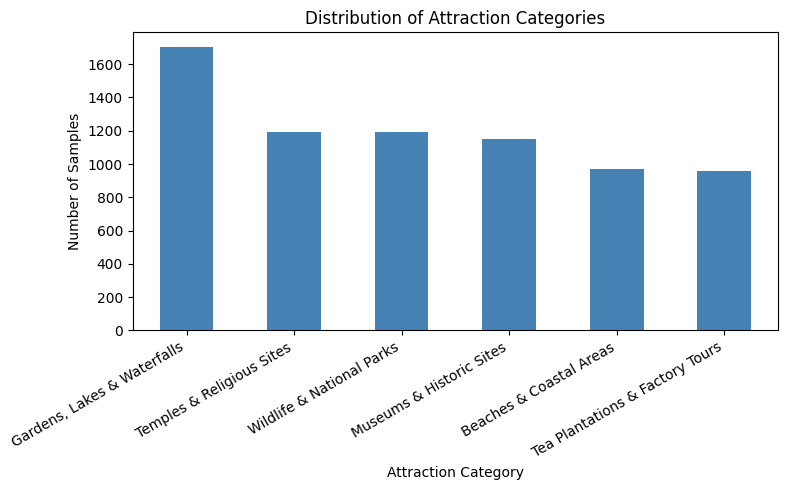

In [ ]:
plt.figure(figsize=(8, 5))

category_counts.plot(
    kind="bar",
    color="steelblue",
    #edgecolor="black"
)

plt.title("Distribution of Attraction Categories")
plt.xlabel("Attraction Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
cols = ['Title', 'Text']

for col in cols:
    df[col] = df[col].fillna('')

df['Combined_Text'] = (
    df['Title'] + ' ' +
    df['Text']
)

cleaned_texts = []
for text in df["Combined_Text"]:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    cleaned_texts.append(text)
df["Combined_Text"] = cleaned_texts

In [ ]:
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['Attraction_Category'])

# Save mapping
label_mapping = dict(
    zip(label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_))
)

print(label_mapping)

{'Beaches & Coastal Areas': np.int64(0), 'Gardens, Lakes & Waterfalls': np.int64(1), 'Museums & Historic Sites': np.int64(2), 'Tea Plantations & Factory Tours': np.int64(3), 'Temples & Religious Sites': np.int64(4), 'Wildlife & National Parks': np.int64(5)}


In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

(5731, 13)
(1433, 13)


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

In [ ]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["Combined_Text"],
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/5731 [00:00<?, ? examples/s]

Map:   0%|          | 0/1433 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

# Keep only needed columns
columns_to_keep = [
    'input_ids',
    'attention_mask',
    'labels'
]

train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names
     if col not in columns_to_keep]
)

val_dataset = val_dataset.remove_columns(
    [col for col in val_dataset.column_names
     if col not in columns_to_keep]
)

# Torch format
train_dataset.set_format("torch")
val_dataset.set_format("torch")

# Verify
print(train_dataset.column_names)

['labels', 'input_ids', 'attention_mask']


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./Attraction_predict_results_RA_Roberta_(26/07/07)",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=8,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_dir='./logs'
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    #tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.251700,0.916260,0.919134,0.916260,0.916789
2,0.413868,0.297399,0.918353,0.919552,0.918353,0.918114
3,0.166595,0.357417,0.926029,0.926442,0.926029,0.925831
4,0.166595,0.413198,0.928123,0.930028,0.928123,0.928391
5,0.070334,0.375965,0.929518,0.929424,0.929518,0.929278
6,0.043278,0.450216,0.927425,0.928207,0.927425,0.927424
7,0.013229,0.461336,0.926029,0.926332,0.926029,0.926053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2513, training_loss=0.14073842567852352, metrics={'train_runtime': 1873.5056, 'train_samples_per_second': 24.472, 'train_steps_per_second': 1.533, 'total_flos': 4391275662751680.0, 'train_loss': 0.14073842567852352, 'epoch': 7.0})

In [ ]:
import pandas as pd

# Convert training history to DataFrame
log_history = pd.DataFrame(trainer.state.log_history)

# Display available columns
print(log_history.columns)

log_history.head()

Index(['eval_loss', 'eval_accuracy', 'eval_precision', 'eval_recall',
       'eval_f1', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second', 'epoch', 'step', 'loss', 'grad_norm',
       'learning_rate', 'train_runtime', 'train_samples_per_second',
       'train_steps_per_second', 'total_flos', 'train_loss'],
      dtype='object')


,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step,loss,grad_norm,learning_rate,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.251700,0.916260,0.919134,0.916260,0.916789,18.2186,78.656,4.940,1.000000,359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.392758,500,0.413868,26.337276,0.000017,NaN,NaN,NaN,NaN,NaN
2,0.297399,0.918353,0.919552,0.918353,0.918114,18.2460,78.538,4.933,2.000000,718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.785515,1000,0.166595,13.753661,0.000013,NaN,NaN,NaN,NaN,NaN
4,0.357417,0.926029,0.926442,0.926029,0.925831,18.4198,77.797,4.886,3.000000,1077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


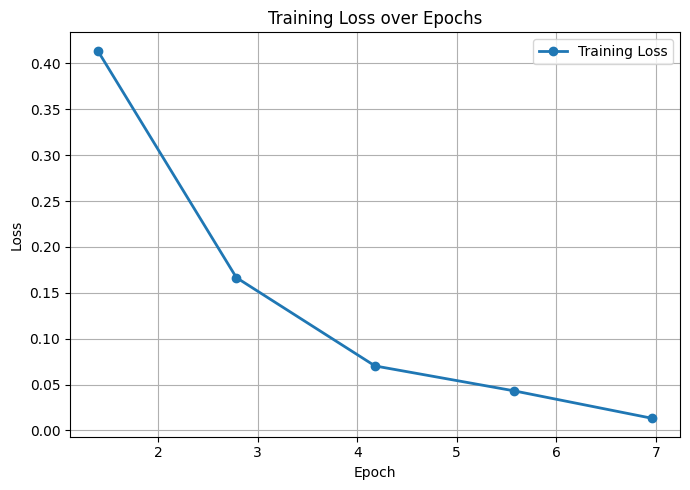

In [ ]:
import matplotlib.pyplot as plt

train_loss = log_history[log_history["loss"].notna()]

plt.figure(figsize=(7,5))

plt.plot(
    train_loss["epoch"],
    train_loss["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

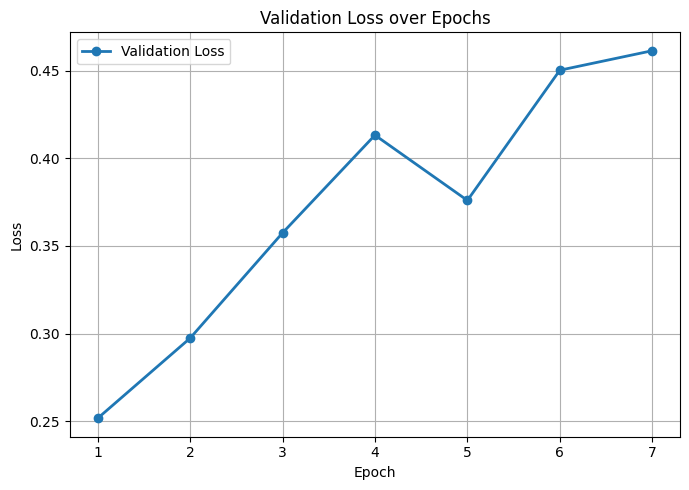

In [ ]:
eval_loss = log_history[log_history["eval_loss"].notna()]

plt.figure(figsize=(7,5))

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss over Epochs")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

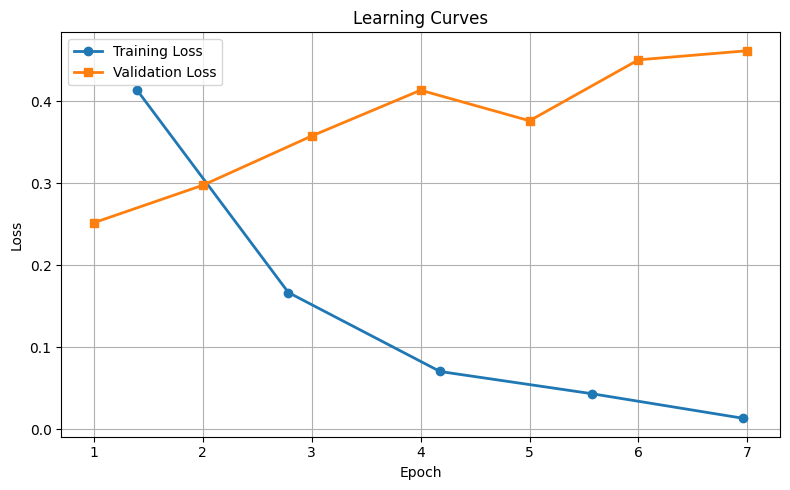

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_loss["epoch"],
    train_loss["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

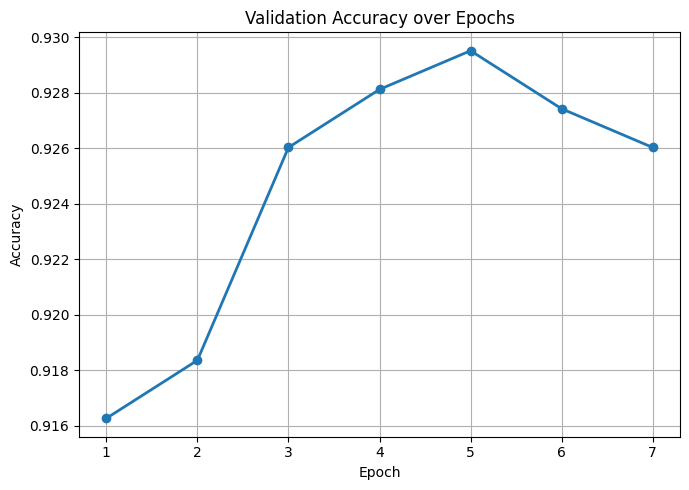

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
predictions = trainer.predict(val_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(
    classification_report(
        predictions.label_ids,
        preds,
        target_names=label_encoder.classes_
    )
)

                                 precision    recall  f1-score   support

        Beaches & Coastal Areas       0.93      0.94      0.94       194
    Gardens, Lakes & Waterfalls       0.92      0.91      0.92       341
       Museums & Historic Sites       0.93      0.87      0.90       230
Tea Plantations & Factory Tours       0.95      0.97      0.96       192
      Temples & Religious Sites       0.91      0.93      0.92       238
      Wildlife & National Parks       0.94      0.96      0.95       238

                       accuracy                           0.93      1433
                      macro avg       0.93      0.93      0.93      1433
                   weighted avg       0.93      0.93      0.93      1433



In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    predictions.label_ids,
    preds,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = (
    pd.DataFrame(report)
      .transpose()
      .iloc[:-3]
)

report_df

,precision,recall,f1-score,support
Beaches & Coastal Areas,0.928934,0.943299,0.936061,194.0
"Gardens, Lakes & Waterfalls",0.920354,0.914956,0.917647,341.0
Museums & Historic Sites,0.925926,0.869565,0.896861,230.0
Tea Plantations & Factory Tours,0.954082,0.973958,0.963918,192.0
Temples & Religious Sites,0.913580,0.932773,0.923077,238.0
Wildlife & National Parks,0.942149,0.957983,0.950000,238.0


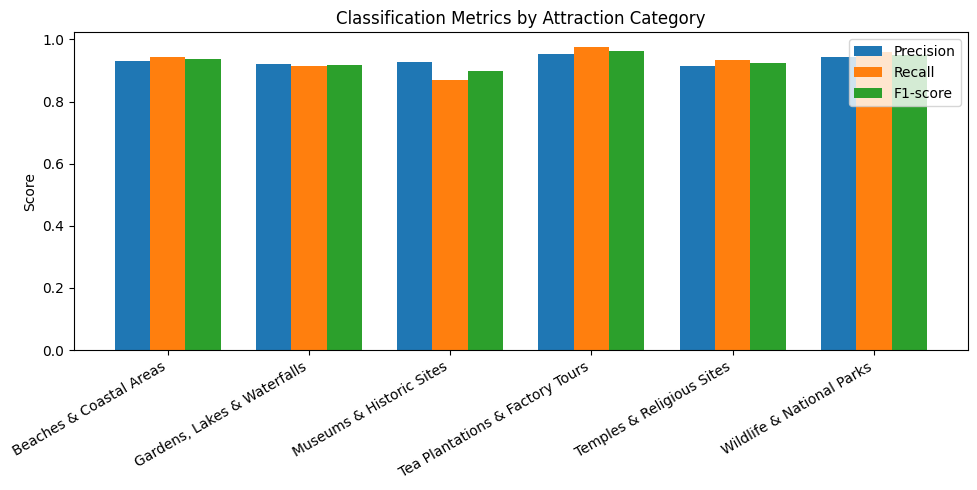

In [ ]:
plt.figure(figsize=(10,5))

x = range(len(report_df))

width = 0.25

plt.bar(
    [i-width for i in x],
    report_df["precision"],
    width=width,
    label="Precision"
)

plt.bar(
    x,
    report_df["recall"],
    width=width,
    label="Recall"
)

plt.bar(
    [i+width for i in x],
    report_df["f1-score"],
    width=width,
    label="F1-score"
)

plt.xticks(
    x,
    report_df.index,
    rotation=30,
    ha="right"
)

plt.ylabel("Score")
plt.title("Classification Metrics by Attraction Category")

plt.legend()

plt.tight_layout()

plt.show()

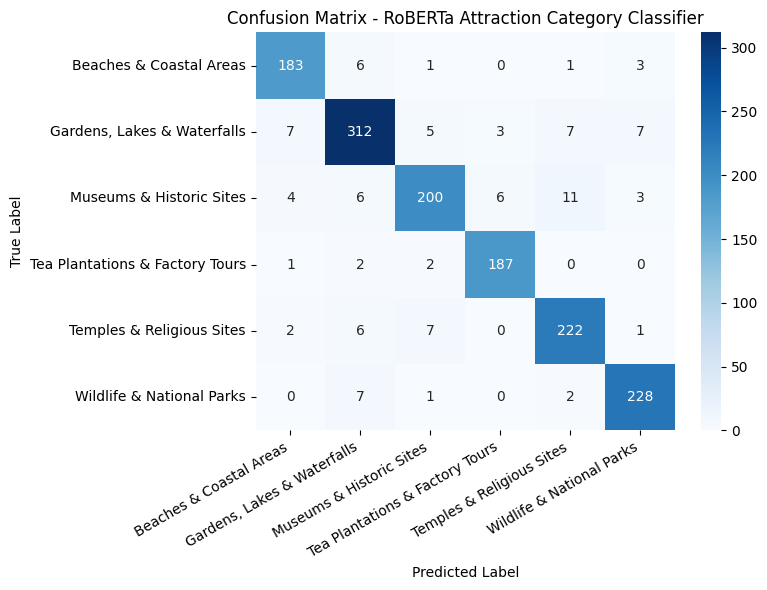

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    predictions.label_ids,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RoBERTa Attraction Category Classifier")

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

sample_text = """
samadhi Buddha Statue
Beautiful sacred temple with historic importance.
"""

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

predicted_class = torch.argmax(outputs.logits, dim=1).item()

print(predicted_class)

4


In [ ]:
trainer.save_model("/content/Attraction Prediction Model_3_(Roberta)_(26/07/07)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
tokenizer.save_pretrained("/content/Attraction Prediction Model_3_(Roberta)_(26/07/07)")

('/content/Attraction Prediction Model_3_(Roberta)_(26/07/07)/tokenizer_config.json',
 '/content/Attraction Prediction Model_3_(Roberta)_(26/07/07)/tokenizer.json')

In [ ]:
import shutil

shutil.make_archive(
    "/content/Attraction Prediction Model_3_(Roberta)_(26/07/07)",
    "zip",
    "/content/Attraction Prediction Model_3_(Roberta)_(26/07/07)"
)

'/content/Attraction Prediction Model_3_(Roberta)_(26/07/07).zip'

In [ ]:
from google.colab import files
files.download("/content/Attraction Prediction Model_3_(Roberta)_(26/07/07).zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json

input_file = "/content/drive/MyDrive/Colab Notebooks/Attraction Prediction Model_3 (Roberta)_1.ipynb"
output_file = "/content/drive/MyDrive/Colab Notebooks/Attraction Prediction Model_3 (Roberta)_1.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Clean notebook saved for GitHub:", output_file)

Clean notebook saved for GitHub: /content/drive/MyDrive/Colab Notebooks/Attraction Prediction Model_3 (Roberta)_1.ipynb
